# Project : Sentiment Analysis

In [1]:
import numpy as np
import pandas as pd


import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('datasets/sentiment-analysis.csv')
print(df.columns)
print()
print(df)

Index(['Text, Sentiment, Source, Date/Time, User ID, Location, Confidence Score'], dtype='str')

   Text, Sentiment, Source, Date/Time, User ID, Location, Confidence Score
0   "I love this product!", Positive, Twitter, 202...                     
1   "The service was terrible.", Negative, Yelp Re...                     
2   "This movie is amazing!", Positive, IMDb, 2023...                     
3   "I'm so disappointed with their customer suppo...                     
4   "Just had the best meal of my life!", Positive...                     
..                                                ...                     
93  "I can't stop listening to this song. It's my ...                     
94  "Their website is so confusing and poorly desi...                     
95  "I had an incredible experience at the theme p...                     
96                                                NaN                     
97                                                NaN                     

[9

In [3]:
df[:1]

,"Text, Sentiment, Source, Date/Time, User ID, Location, Confidence Score"
0,"""I love this product!"", Positive, Twitter, 202..."


In [4]:
print(df.isna().sum())

df = df.dropna()
print(df.isna().sum())

Text, Sentiment, Source, Date/Time, User ID, Location, Confidence Score    2
dtype: int64
Text, Sentiment, Source, Date/Time, User ID, Location, Confidence Score    0
dtype: int64


In [5]:
data = df['Text, Sentiment, Source, Date/Time, User ID, Location, Confidence Score'].str.split(',', expand=True)
data.columns = ['text', 'sentiment', 'source', 'date/time', 'ID', 'location', 'confidence_score']
data.head(20)

,text,sentiment,source,date/time,ID,location,confidence_score
0,"""I love this product!""",Positive,Twitter,2023-06-15 09:23:14,@user123,New York,0.85
1,"""The service was terrible.""",Negative,Yelp Reviews,2023-06-15 11:45:32,user456,Los Angeles,0.65
2,"""This movie is amazing!""",Positive,IMDb,2023-06-15 14:10:22,moviefan789,London,0.92
3,"""I'm so disappointed with their customer suppo...",Negative,Online Forum,2023-06-15 17:35:11,forumuser1,Toronto,0.78
4,"""Just had the best meal of my life!""",Positive,TripAdvisor,2023-06-16 08:50:59,foodie22,Paris,0.88
5,"""The quality of this product is subpar.""",Negative,Amazon Reviews,2023-06-16 10:15:27,shopper123,San Francisco,0.72
6,"""I can't stop listening to this song. It's inc...",Positive,Spotify,2023-06-16 13:40:18,musiclover456,Berlin,0.91
7,"""Their website is so user-friendly. Love it!""",Positive,Website Testimonial,2023-06-16 16:05:36,testimonialuser1,Sydney,0.87
8,"""I loved the movie! It was fantastic!""",Positive,IMDb,2023-07-02 09:12:34,user123,New York,0.92
9,"""The customer service was terrible.""",Negative,Yelp Reviews,2023-07-02 10:45:21,user456,Los Angeles,0.65


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   text              96 non-null     str  
 1   sentiment         96 non-null     str  
 2   source            96 non-null     str  
 3   date/time         96 non-null     str  
 4   ID                96 non-null     str  
 5   location          96 non-null     str  
 6   confidence_score  96 non-null     str  
dtypes: str(7)
memory usage: 5.4 KB


In [7]:
data['confidence_score'] = data['confidence_score'].astype(float)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   text              96 non-null     str    
 1   sentiment         96 non-null     str    
 2   source            96 non-null     str    
 3   date/time         96 non-null     str    
 4   ID                96 non-null     str    
 5   location          96 non-null     str    
 6   confidence_score  96 non-null     float64
dtypes: float64(1), str(6)
memory usage: 5.4 KB


In [8]:
print('Duplicate items are : ', data.duplicated(subset=['ID']).sum())   # checking duplicates based on user ID


Duplicate items are :  23


In [9]:
print(data.shape)

data = data.drop_duplicates(subset=['ID'])
print(data.shape)

(96, 7)
(73, 7)


In [10]:
data.describe()

,confidence_score
count,73.000000
mean,0.798356
std,0.134092
min,0.550000
25%,0.670000
50%,0.870000
75%,0.920000
max,0.950000


In [11]:
# importing stopwords
import nltk
from nltk.corpus import stopwords               # removes stopwords
stop_words = stopwords.words('english')

# importing porterstemmer
from nltk.stem.porter import PorterStemmer     # stemming brings a word to its root form
st = PorterStemmer()


# importing cleantext to remove symbols
from cleantext import clean                    # can do both stopword removal, and can also do stemming





In [12]:
# printing all the stop words nltk has
print(len(stop_words))
print(stop_words)

198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 

In [13]:
print(st.stem('hii this is jeet, playing, running, shouring, screams'))

hii this is jeet, playing, running, shouring, scream


In [14]:
nltk.word_tokenize('hii this is jeet !!!')

['hii', 'this', 'is', 'jeet', '!', '!', '!']

In [15]:
help(nltk.word_tokenize)

Help on function word_tokenize in module nltk.tokenize:

word_tokenize(text, language='english', preserve_line=False)
    Return a tokenized copy of *text*,
    using NLTK's recommended word tokenizer
    (currently an improved :class:`.TreebankWordTokenizer`
    along with :class:`.PunktSentenceTokenizer`
    for the specified language).

    :param text: text to split into words
    :type text: str
    :param language: the model name in the Punkt corpus
    :type language: str
    :param preserve_line: A flag to decide whether to sentence tokenize the text or not.
    :type preserve_line: bool



In [16]:
help(nltk.WordNetLemmatizer)

Help on class WordNetLemmatizer in module nltk.stem.wordnet:

class WordNetLemmatizer(builtins.object)
 |  WordNet Lemmatizer
 |
 |  Provides 3 lemmatizer modes: _morphy(), morphy() and lemmatize().
 |
 |  lemmatize() is a permissive wrapper around _morphy().
 |  It returns the shortest lemma found in WordNet,
 |  or the input string unchanged if nothing is found.
 |
 |  >>> from nltk.stem import WordNetLemmatizer as wnl
 |  >>> print(wnl().lemmatize('us', 'n'))
 |  u
 |
 |  >>> print(wnl().lemmatize('Anythinggoeszxcv'))
 |  Anythinggoeszxcv
 |
 |  Methods defined here:
 |
 |  __repr__(self)
 |      Return repr(self).
 |
 |  lemmatize(self, word: str, pos: str = 'n') -> str
 |      Lemmatize `word` by picking the shortest of the possible lemmas,
 |      using the wordnet corpus reader's built-in _morphy function.
 |      Returns the input word unchanged if it cannot be found in WordNet.
 |
 |      >>> from nltk.stem import WordNetLemmatizer as wnl
 |      >>> print(wnl().lemmatize('dog

In [17]:
txt = 'hii this is Jeet !!!, I always go to gym for better body and physiche, I make a very good living.'
clean(txt, stemming=True, stopwords=True, lowercase=True, punct=True)

'hii jeet alway go gym better bodi physich make good live'

In [18]:
# checking for all the keywords used in clean
help(clean)

Help on function clean in module cleantext.cleantext:

clean(text: str, clean_all: bool = True, extra_spaces: bool = False, stemming: bool = False, stopwords: bool = False, lowercase: bool = False, numbers: bool = False, punct: bool = False, reg: str = '', reg_replace: str = '', stp_lang: str = 'english') -> str
    Given a raw string, return cleaned text

    :param text: Input text to clean
    :param clean_all: Execute all cleaning operations
    :param extra_spaces: Remove extra white spaces
    :param stemming: Stem the words
    :param stopwords: Remove stop words
    :param lowercase: Convert to lowercase
    :param numbers: Remove all digits
    :param punct: Remove all punctuations
    :param reg: Regular expression for removing or replacing
    :param reg_replace: Replace the part with regular expression(reg)
    :param stp_lang: Language for stop words
    :return: Cleaned text



# Cleantext vs. NLTK: Which one to use?

The `cleantext` library is incredibly convenient because it acts as an "all-in-one" wrapper. For basic machine learning projects, setting `stemming=True` and `stopwords=True` in `cleantext` is a great way to save time.

However, Data Scientists transition to a heavier library like **NLTK** when they need **Control, Customization, and Advanced Features**.

### 1. Customizing Stopwords
When you use `stopwords=True` in `cleantext`, it uses a hidden, pre-defined list of words to remove. 
*   **The Problem:** In Sentiment Analysis, words like *"not"*, *"don't"*, or *"didn't"* are usually on standard stopword lists. If `cleantext` removes them, "The movie was not good" becomes "movie good"—completely destroying the meaning.
*   **The NLTK Solution:** In NLTK, the stopwords are loaded as a standard Python list. You can easily modify it before cleaning: `my_stopwords.remove("not")` or `my_stopwords.append("custom_word")`.

### 2. Choice of Stemmer vs. Lemmatization
`cleantext` uses one default method for stemming. 
*   **The NLTK Solution:** NLTK gives you options. You can choose the gentle *SnowballStemmer*, the highly aggressive *LancasterStemmer*, or completely bypass stemming to use **Lemmatization** (which turns "better" into "good" using a real linguistic dictionary). `cleantext` does not support Lemmatization.

### 3. Advanced Linguistic Tasks
Cleaning is only the first step of NLP. If you want to move beyond simple word counts, you need NLTK's advanced toolkit:
*   **Part of Speech (POS) Tagging:** Identifying if a word is a Noun, Verb, or Adjective.
*   **Named Entity Recognition (NER):** Automatically identifying that "Apple" in a sentence refers to the company, not the fruit.

---

### Summary
*   **Use `cleantext`** when you want a fast, easy, "black-box" cleaning pipeline and you don't care about fine-tuning the details.
*   **Use `nltk`** when your model's accuracy depends on keeping specific stopwords, choosing specific grammatical roots, or performing advanced text analysis.


In [19]:
data.head(10)

,text,sentiment,source,date/time,ID,location,confidence_score
0,"""I love this product!""",Positive,Twitter,2023-06-15 09:23:14,@user123,New York,0.85
1,"""The service was terrible.""",Negative,Yelp Reviews,2023-06-15 11:45:32,user456,Los Angeles,0.65
2,"""This movie is amazing!""",Positive,IMDb,2023-06-15 14:10:22,moviefan789,London,0.92
3,"""I'm so disappointed with their customer suppo...",Negative,Online Forum,2023-06-15 17:35:11,forumuser1,Toronto,0.78
4,"""Just had the best meal of my life!""",Positive,TripAdvisor,2023-06-16 08:50:59,foodie22,Paris,0.88
5,"""The quality of this product is subpar.""",Negative,Amazon Reviews,2023-06-16 10:15:27,shopper123,San Francisco,0.72
6,"""I can't stop listening to this song. It's inc...",Positive,Spotify,2023-06-16 13:40:18,musiclover456,Berlin,0.91
7,"""Their website is so user-friendly. Love it!""",Positive,Website Testimonial,2023-06-16 16:05:36,testimonialuser1,Sydney,0.87
8,"""I loved the movie! It was fantastic!""",Positive,IMDb,2023-07-02 09:12:34,user123,New York,0.92
10,"""This book made me feel inspired. Highly recom...",Positive,Goodreads,2023-07-02 12:34:56,bookworm789,London,0.88


In [20]:
stop_words = stopwords.words('english')


In [21]:
from nltk.stem import WordNetLemmatizer
lmt = WordNetLemmatizer()

In [22]:
def transform(text):
    # using clean to covert into lowercase and remove the punctuations
    text = clean(
        text,
        stemming=False,
        lowercase=True,
        punct=True,
        stopwords=False
    )

    # using word_tokenizer
    text = nltk.word_tokenize(text)

    temp = []
    # stemming and removing stopwords
    for word in text:
        if word not in stop_words:
            word = lmt.lemmatize(word, pos='v')
            temp.append(word)

    text = " ".join(temp)
    return text

In [23]:
print(transform('Hello this is Ashura !!!, i am happily living my life'))
print(transform('CRYING, playing, plays, goes'))

hello ashura happily live life
cry play play go


In [24]:
a = data['text'].apply(transform)
a

0                                          love product
1                                      service terrible
2                                           movie amaze
3                        im disappoint customer support
4                                        best meal life
                            ...                        
69    website navigation smooth intuitive find need ...
70    ride cruise ship unforgettable experience love...
71               product receive poor quality break use
72           book keep hook start finish captivate read
73    customer service store outstanding truly care ...
Name: text, Length: 73, dtype: str

---

In [25]:
from cleantext import clean

import nltk

from nltk.tokenize import word_tokenize

from nltk.corpus import stopwords
stop_words = stopwords.words('english')

from nltk.stem import WordNetLemmatizer
lmt = WordNetLemmatizer()


In [26]:
def change(text):
    text = clean(
        text,
        lowercase=True,
        punct=True,
        stemming=False
    )

    text = nltk.word_tokenize(text)

    temp = []
    for word in text:
        if word not in stop_words:
            word = lmt.lemmatize(word, pos='v')
            temp.append(word)
    
    return " ".join(temp)

    

In [27]:
change('hello, plays, writing')

'hello play write'

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()

In [29]:
data['text_transformed'] = data['text'].apply(change)

matrix = tfidf.fit_transform(data['text_transformed'])

print(matrix.toarray().shape)
matrix.toarray()

(73, 216)


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(73, 216))

In [30]:
print(len(tfidf.get_feature_names_out()))
print(tfidf.get_feature_names_out())


216
['absolutely' 'addict' 'adrenaline' 'air' 'album' 'always' 'amaze'
 'arrive' 'art' 'artists' 'avoid' 'away' 'awe' 'awful' 'back' 'band'
 'beautifully' 'best' 'beyond' 'blow' 'book' 'bore' 'break' 'breath'
 'breathtaking' 'cafe' 'calm' 'cant' 'captivate' 'care' 'chat' 'clutter'
 'coaster' 'concert' 'confuse' 'contagious' 'cost' 'couldnt' 'cruise'
 'customer' 'customers' 'damage' 'delay' 'delicious' 'delivery' 'design'
 'difficult' 'disappoint' 'easy' 'electrify' 'end' 'energize' 'energy'
 'enough' 'ever' 'every' 'exceed' 'excellent' 'exceptional' 'excitement'
 'exhilarate' 'expectations' 'experience' 'extremely' 'fantastic'
 'favorite' 'feel' 'feelgood' 'fell' 'find' 'finest' 'finish' 'flat'
 'flight' 'follow' 'food' 'fresh' 'friendly' 'frustrate' 'frustratingly'
 'fun' 'game' 'get' 'go' 'good' 'goto' 'great' 'hard' 'headphones'
 'heartpounding' 'helpful' 'highly' 'hook' 'hotel' 'im' 'impress'
 'improvement' 'incredible' 'information' 'inspire' 'intuitive' 'issue'
 'keep' 'know' 'la

In [31]:
data_math = pd.DataFrame(matrix.toarray(), columns=tfidf.get_feature_names_out())
print(data_math.shape)
data_math.sample(10)

(73, 216)


,absolutely,addict,adrenaline,air,album,always,amaze,arrive,art,artists,...,vacation,wait,website,week,within,work,workouts,worst,worth,write
26,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.463056,0.0,0.000000,0.0
36,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0
6,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0
17,0.380073,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0
0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0
66,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.544991,0.0
4,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0
54,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0
49,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0
15,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0


In [32]:
data

,text,sentiment,source,date/time,ID,location,confidence_score,text_transformed
0,"""I love this product!""",Positive,Twitter,2023-06-15 09:23:14,@user123,New York,0.85,love product
1,"""The service was terrible.""",Negative,Yelp Reviews,2023-06-15 11:45:32,user456,Los Angeles,0.65,service terrible
2,"""This movie is amazing!""",Positive,IMDb,2023-06-15 14:10:22,moviefan789,London,0.92,movie amaze
3,"""I'm so disappointed with their customer suppo...",Negative,Online Forum,2023-06-15 17:35:11,forumuser1,Toronto,0.78,im disappoint customer support
4,"""Just had the best meal of my life!""",Positive,TripAdvisor,2023-06-16 08:50:59,foodie22,Paris,0.88,best meal life
...,...,...,...,...,...,...,...,...
69,"""The website navigation is smooth and intuitiv...",Positive,Website Testimonial,2023-07-15 21:05:44,happyuser123,Toronto,0.88,website navigation smooth intuitive find need ...
70,"""The ride on this cruise ship was an unforgett...",Positive,Travel Blog,2023-07-16 09:12:54,travelenthusiast2,Sydney,0.95,ride cruise ship unforgettable experience love...
71,"""The product I received was of poor quality. I...",Negative,Online Store,2023-07-16 11:45:32,shopper567,Los Angeles,0.61,product receive poor quality break use
72,"""This book kept me hooked from start to finish...",Positive,Goodreads,2023-07-16 14:23:18,bookworm7890,London,0.90,book keep hook start finish captivate read


In [33]:
# applying label encoder on sentiment

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['sentiment'] = le.fit_transform(data['sentiment'])
data.head()


,text,sentiment,source,date/time,ID,location,confidence_score,text_transformed
0,"""I love this product!""",1,Twitter,2023-06-15 09:23:14,@user123,New York,0.85,love product
1,"""The service was terrible.""",0,Yelp Reviews,2023-06-15 11:45:32,user456,Los Angeles,0.65,service terrible
2,"""This movie is amazing!""",1,IMDb,2023-06-15 14:10:22,moviefan789,London,0.92,movie amaze
3,"""I'm so disappointed with their customer suppo...",0,Online Forum,2023-06-15 17:35:11,forumuser1,Toronto,0.78,im disappoint customer support
4,"""Just had the best meal of my life!""",1,TripAdvisor,2023-06-16 08:50:59,foodie22,Paris,0.88,best meal life


In [34]:
# checking what words did it changed it to what numbers

for nums, words in enumerate(le.classes_):
    print(f"The num : {nums} -- represents : '{words}")

The num : 0 -- represents : ' Negative
The num : 1 -- represents : ' Positive


In [35]:
print(len(data['source'].unique()))
print(data['source'].unique())

27
<StringArray>
[            ' Twitter',        ' Yelp Reviews',                ' IMDb',
        ' Online Forum',         ' TripAdvisor',      ' Amazon Reviews',
             ' Spotify', ' Website Testimonial',           ' Goodreads',
        ' Online Store',              ' Zomato',      ' Website Review',
         ' Trip Report',        ' Event Review',         ' Online Chat',
      ' Airline Review',   ' Theme Park Review',        ' Music Review',
        ' Retail Store',     ' Online Helpdesk',        ' Gaming Forum',
      ' Travel Website',        ' Hotel Review',           ' Food Blog',
      ' TV Show Review',          ' Art Review',         ' Travel Blog']
Length: 27, dtype: str


### EDA

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

In [37]:
# The .values forces Pandas to ignore the index and just glue the column straight on!

data_math['sentiment'] = data['sentiment'].values
data_math

,absolutely,addict,adrenaline,air,album,always,amaze,arrive,art,artists,...,wait,website,week,within,work,workouts,worst,worth,write,sentiment
0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.727522,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.272418,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
69,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
70,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
71,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [38]:
grouped_math = data_math.groupby('sentiment').mean(numeric_only=True)
grouped_math

,absolutely,addict,adrenaline,air,album,always,amaze,arrive,art,artists,...,vacation,wait,website,week,within,work,workouts,worst,worth,write
sentiment,,,,,,,,,,,,,,,,,,,,,
0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.057509,0.000000,0.000000,...,0.000000,0.000000,0.054810,0.013716,0.013716,0.000000,0.000000,0.014259,0.01758,0.000000
1,0.02699,0.011815,0.009589,0.008579,0.010397,0.016763,0.035762,0.000000,0.010397,0.010412,...,0.011226,0.020419,0.025333,0.000000,0.000000,0.010397,0.011025,0.000000,0.00000,0.010795


In [39]:
positive = grouped_math.iloc[1].sort_values(ascending=False).head(30)
negative = grouped_math.iloc[0].sort_values(ascending=False).head(30)
print(len(positive))
print(len(negative))
print(positive)
print()
print(negative)

30
30
love            0.052476
cant            0.043098
song            0.039809
recommend       0.039317
highly          0.039317
movie           0.039195
amaze           0.035762
customer        0.035252
food            0.033204
best            0.033092
band            0.032294
store           0.031407
incredible      0.029374
go              0.027290
restaurant      0.027022
absolutely      0.026990
concert         0.026907
im              0.026382
roller          0.025908
coaster         0.025908
userfriendly    0.025511
website         0.025333
ride            0.025042
put             0.024739
service         0.024062
book            0.023705
outstanding     0.021803
stop            0.021419
listen          0.021419
masterpiece     0.021134
Name: 1, dtype: float64

disappoint        0.107125
product           0.102444
terrible          0.097768
service           0.074499
customer          0.069242
im                0.068602
experience        0.061565
support           0.060856
arr

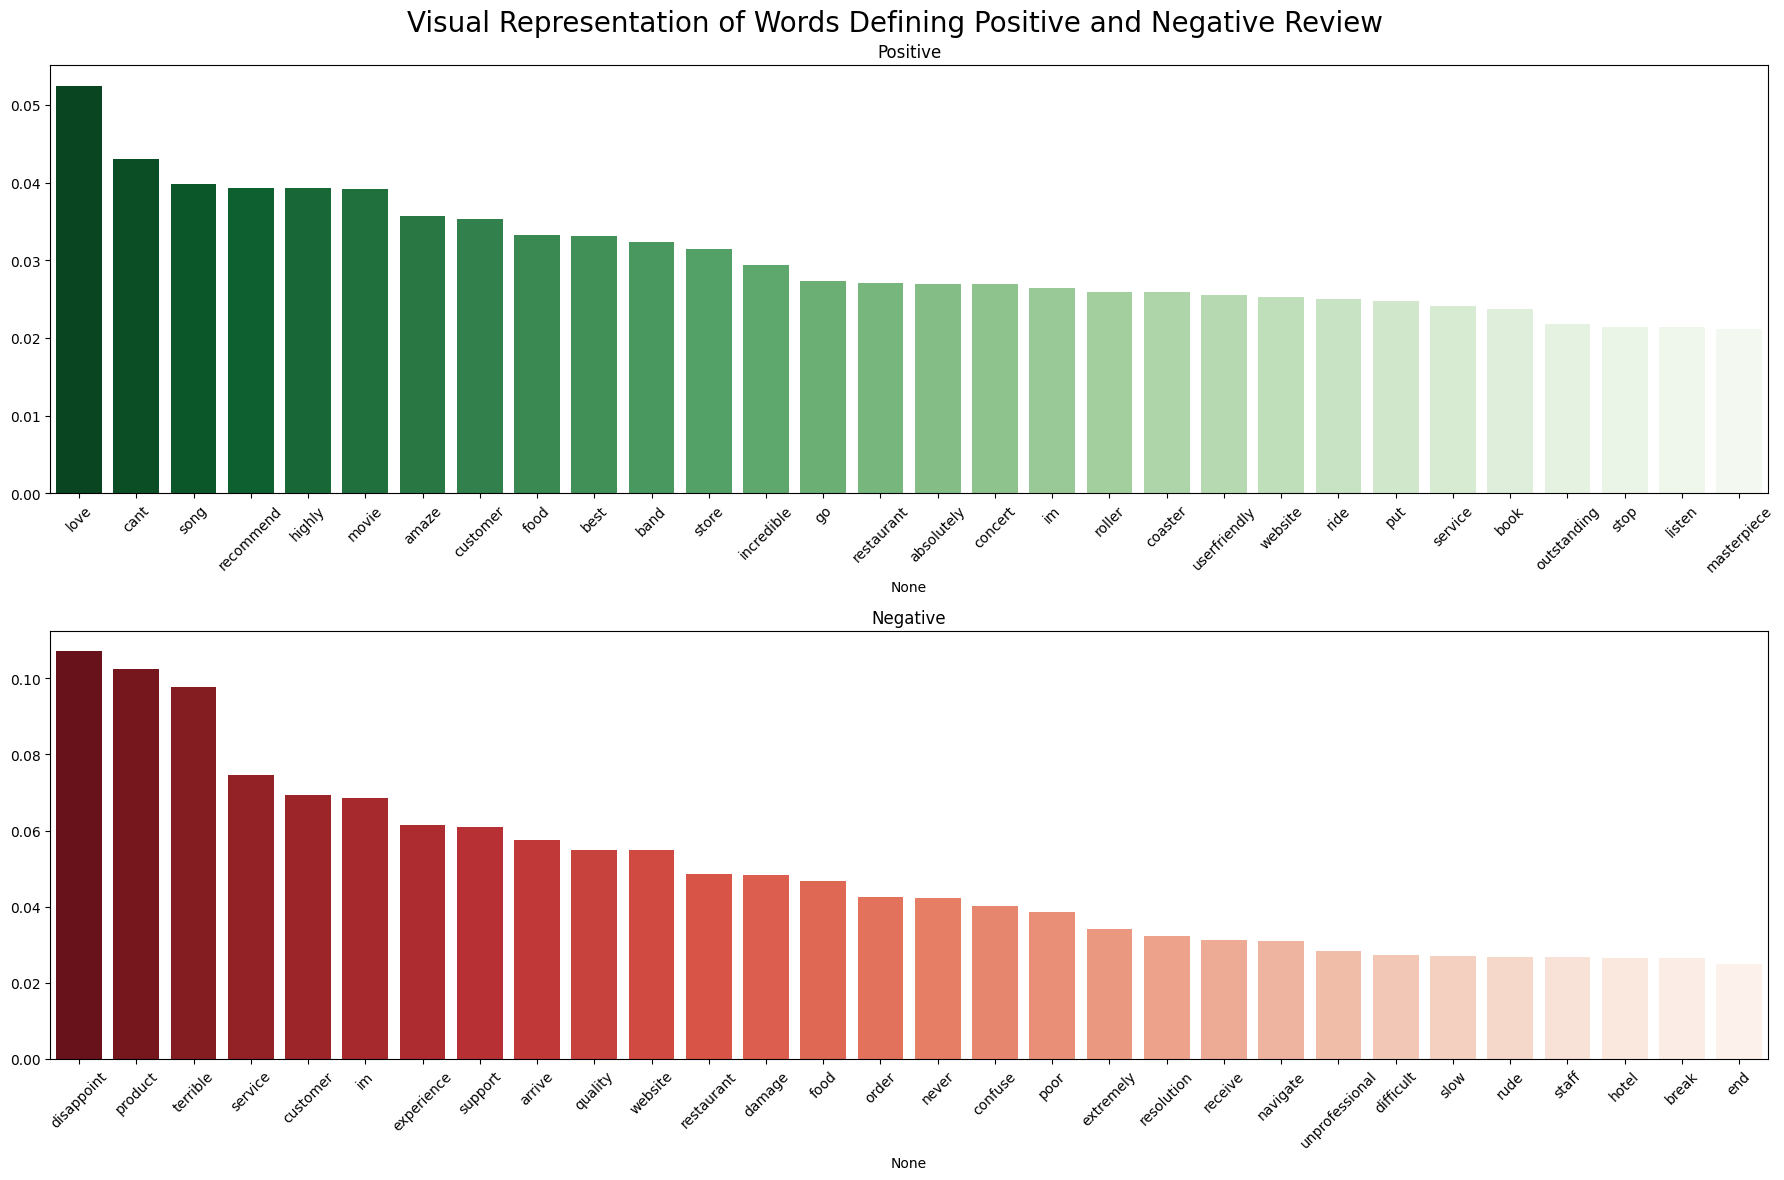

In [40]:
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

sns.barplot(x=positive.index, y=positive.values, ax=axes[0], palette='Greens_r')    
axes[0].set_title('Positive')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x=negative.index, y=negative.values, ax=axes[1], palette='Reds_r')
axes[1].set_title('Negative')
axes[1].tick_params(axis='x', rotation=45)


plt.suptitle("Visual Representation of Words Defining Positive and Negative Review", fontsize=20)
plt.tight_layout()
plt.show()

In [41]:
data

,text,sentiment,source,date/time,ID,location,confidence_score,text_transformed
0,"""I love this product!""",1,Twitter,2023-06-15 09:23:14,@user123,New York,0.85,love product
1,"""The service was terrible.""",0,Yelp Reviews,2023-06-15 11:45:32,user456,Los Angeles,0.65,service terrible
2,"""This movie is amazing!""",1,IMDb,2023-06-15 14:10:22,moviefan789,London,0.92,movie amaze
3,"""I'm so disappointed with their customer suppo...",0,Online Forum,2023-06-15 17:35:11,forumuser1,Toronto,0.78,im disappoint customer support
4,"""Just had the best meal of my life!""",1,TripAdvisor,2023-06-16 08:50:59,foodie22,Paris,0.88,best meal life
...,...,...,...,...,...,...,...,...
69,"""The website navigation is smooth and intuitiv...",1,Website Testimonial,2023-07-15 21:05:44,happyuser123,Toronto,0.88,website navigation smooth intuitive find need ...
70,"""The ride on this cruise ship was an unforgett...",1,Travel Blog,2023-07-16 09:12:54,travelenthusiast2,Sydney,0.95,ride cruise ship unforgettable experience love...
71,"""The product I received was of poor quality. I...",0,Online Store,2023-07-16 11:45:32,shopper567,Los Angeles,0.61,product receive poor quality break use
72,"""This book kept me hooked from start to finish...",1,Goodreads,2023-07-16 14:23:18,bookworm7890,London,0.90,book keep hook start finish captivate read


In [42]:
# dropping the unwanted extra spaces in the texts

data['source'] = data['source'].str.strip()
data['location'] = data['location'].str.strip()
data['ID'] = data['ID'].str.strip()

data 

,text,sentiment,source,date/time,ID,location,confidence_score,text_transformed
0,"""I love this product!""",1,Twitter,2023-06-15 09:23:14,@user123,New York,0.85,love product
1,"""The service was terrible.""",0,Yelp Reviews,2023-06-15 11:45:32,user456,Los Angeles,0.65,service terrible
2,"""This movie is amazing!""",1,IMDb,2023-06-15 14:10:22,moviefan789,London,0.92,movie amaze
3,"""I'm so disappointed with their customer suppo...",0,Online Forum,2023-06-15 17:35:11,forumuser1,Toronto,0.78,im disappoint customer support
4,"""Just had the best meal of my life!""",1,TripAdvisor,2023-06-16 08:50:59,foodie22,Paris,0.88,best meal life
...,...,...,...,...,...,...,...,...
69,"""The website navigation is smooth and intuitiv...",1,Website Testimonial,2023-07-15 21:05:44,happyuser123,Toronto,0.88,website navigation smooth intuitive find need ...
70,"""The ride on this cruise ship was an unforgett...",1,Travel Blog,2023-07-16 09:12:54,travelenthusiast2,Sydney,0.95,ride cruise ship unforgettable experience love...
71,"""The product I received was of poor quality. I...",0,Online Store,2023-07-16 11:45:32,shopper567,Los Angeles,0.61,product receive poor quality break use
72,"""This book kept me hooked from start to finish...",1,Goodreads,2023-07-16 14:23:18,bookworm7890,London,0.90,book keep hook start finish captivate read


In [43]:
# printing how many views from what platforms
for i in data['source'].unique():
    print(f"{i} : ", data[data['source'] == i].shape[0])

Twitter :  1
Yelp Reviews :  3
IMDb :  4
Online Forum :  1
TripAdvisor :  4
Amazon Reviews :  1
Spotify :  6
Website Testimonial :  3
Goodreads :  5
Online Store :  10
Zomato :  5
Website Review :  5
Trip Report :  1
Event Review :  3
Online Chat :  4
Airline Review :  1
Theme Park Review :  3
Music Review :  3
Retail Store :  2
Online Helpdesk :  1
Gaming Forum :  1
Travel Website :  1
Hotel Review :  1
Food Blog :  1
TV Show Review :  1
Art Review :  1
Travel Blog :  1


In [44]:
print(data[(data['sentiment'] == 1) & (data['source'])].shape[0])
data[(data['sentiment'] == 1) & (data['source'])]

42


,text,sentiment,source,date/time,ID,location,confidence_score,text_transformed
0,"""I love this product!""",1,Twitter,2023-06-15 09:23:14,@user123,New York,0.85,love product
2,"""This movie is amazing!""",1,IMDb,2023-06-15 14:10:22,moviefan789,London,0.92,movie amaze
4,"""Just had the best meal of my life!""",1,TripAdvisor,2023-06-16 08:50:59,foodie22,Paris,0.88,best meal life
6,"""I can't stop listening to this song. It's inc...",1,Spotify,2023-06-16 13:40:18,musiclover456,Berlin,0.91,cant stop listen song incredible
7,"""Their website is so user-friendly. Love it!""",1,Website Testimonial,2023-06-16 16:05:36,testimonialuser1,Sydney,0.87,website userfriendly love
8,"""I loved the movie! It was fantastic!""",1,IMDb,2023-07-02 09:12:34,user123,New York,0.92,love movie fantastic
10,"""This book made me feel inspired. Highly recom...",1,Goodreads,2023-07-02 12:34:56,bookworm789,London,0.88,book make feel inspire highly recommend
12,"""Just had the most amazing vacation! I can't w...",1,TripAdvisor,2023-07-02 18:01:23,travelenthusiast1,Sydney,0.93,amaze vacation cant wait go back
14,"""I can't stop listening to this song. It's my ...",1,Spotify,2023-07-03 09:17:52,musiclover789,Berlin,0.91,cant stop listen song new favorite
16,"""I had an incredible experience at the theme p...",1,Trip Report,2023-07-03 14:40:05,thrillseeker1,Orlando,0.89,incredible experience theme park much fun


In [45]:
print(data[(data['sentiment'] == 0) & (data['source'])].shape[0])
data[(data['sentiment'] == 0) & (data['source'])]

31


,text,sentiment,source,date/time,ID,location,confidence_score,text_transformed
1,"""The service was terrible.""",0,Yelp Reviews,2023-06-15 11:45:32,user456,Los Angeles,0.65,service terrible
3,"""I'm so disappointed with their customer suppo...",0,Online Forum,2023-06-15 17:35:11,forumuser1,Toronto,0.78,im disappoint customer support
5,"""The quality of this product is subpar.""",0,Amazon Reviews,2023-06-16 10:15:27,shopper123,San Francisco,0.72,quality product subpar
11,"""I'm extremely disappointed with their product...",0,Online Store,2023-07-02 15:21:43,shopper789,San Francisco,0.72,im extremely disappoint product quality
13,"""The food at this restaurant was awful. Never ...",0,Zomato,2023-07-02 20:45:37,foodlover123,Mumbai,0.55,food restaurant awful never go back
15,"""Their website is so confusing and poorly desi...",0,Website Review,2023-07-03 11:59:18,user789,Toronto,0.68,website confuse poorly design
17,"""The product arrived damaged. Very disappointed.""",0,Online Store,2023-07-03 17:25:09,buyer123,Chicago,0.76,product arrive damage disappoint
19,"""I had a terrible experience with their custom...",0,Online Chat,2023-07-04 08:32:41,user1234,Sydney,0.61,terrible experience customer support
22,"""I'm disappointed with the ending of this book...",0,Goodreads,2023-07-04 19:18:53,booklover123,London,0.68,im disappoint end book fell flat
23,"""The product I received was damaged. Unaccepta...",0,Online Store,2023-07-04 21:52:41,buyer789,San Francisco,0.75,product receive damage unacceptable


In [46]:
# checking for whcih location has most of the positive and negative reviews
for i in data['location'].unique():
    print(f"{i:<10}\t\t : {data[(data['sentiment'] == 1) & (data['location'] == i)].shape[0]}")


print("---------------------------------------------------------------------")

for i in data['location'].unique():
    print(f"{i:<10}\t\t : {data[(data['sentiment'] == 0) & (data['location'] == i)].shape[0]}")

New York  		 : 6
Los Angeles		 : 2
London    		 : 7
Toronto   		 : 1
Paris     		 : 6
San Francisco		 : 0
Berlin    		 : 7
Sydney    		 : 7
Mumbai    		 : 2
Orlando   		 : 4
Chicago   		 : 0
---------------------------------------------------------------------
New York  		 : 0
Los Angeles		 : 4
London    		 : 2
Toronto   		 : 6
Paris     		 : 2
San Francisco		 : 5
Berlin    		 : 0
Sydney    		 : 3
Mumbai    		 : 4
Orlando   		 : 0
Chicago   		 : 5


In [47]:
data['location'].sort_values(ascending=False)

41    Toronto
3     Toronto
15    Toronto
69    Toronto
59    Toronto
       ...   
51     Berlin
68     Berlin
6      Berlin
40     Berlin
27     Berlin
Name: location, Length: 73, dtype: str

In [112]:
location = data['location'].value_counts().sort_index()         # sort_index() -- will sort the words in alphabetical order
location_positive = data[data['sentiment']==1]['location'].value_counts().sort_index()
location_negative = data[data['sentiment']==0]['location'].value_counts().sort_index()

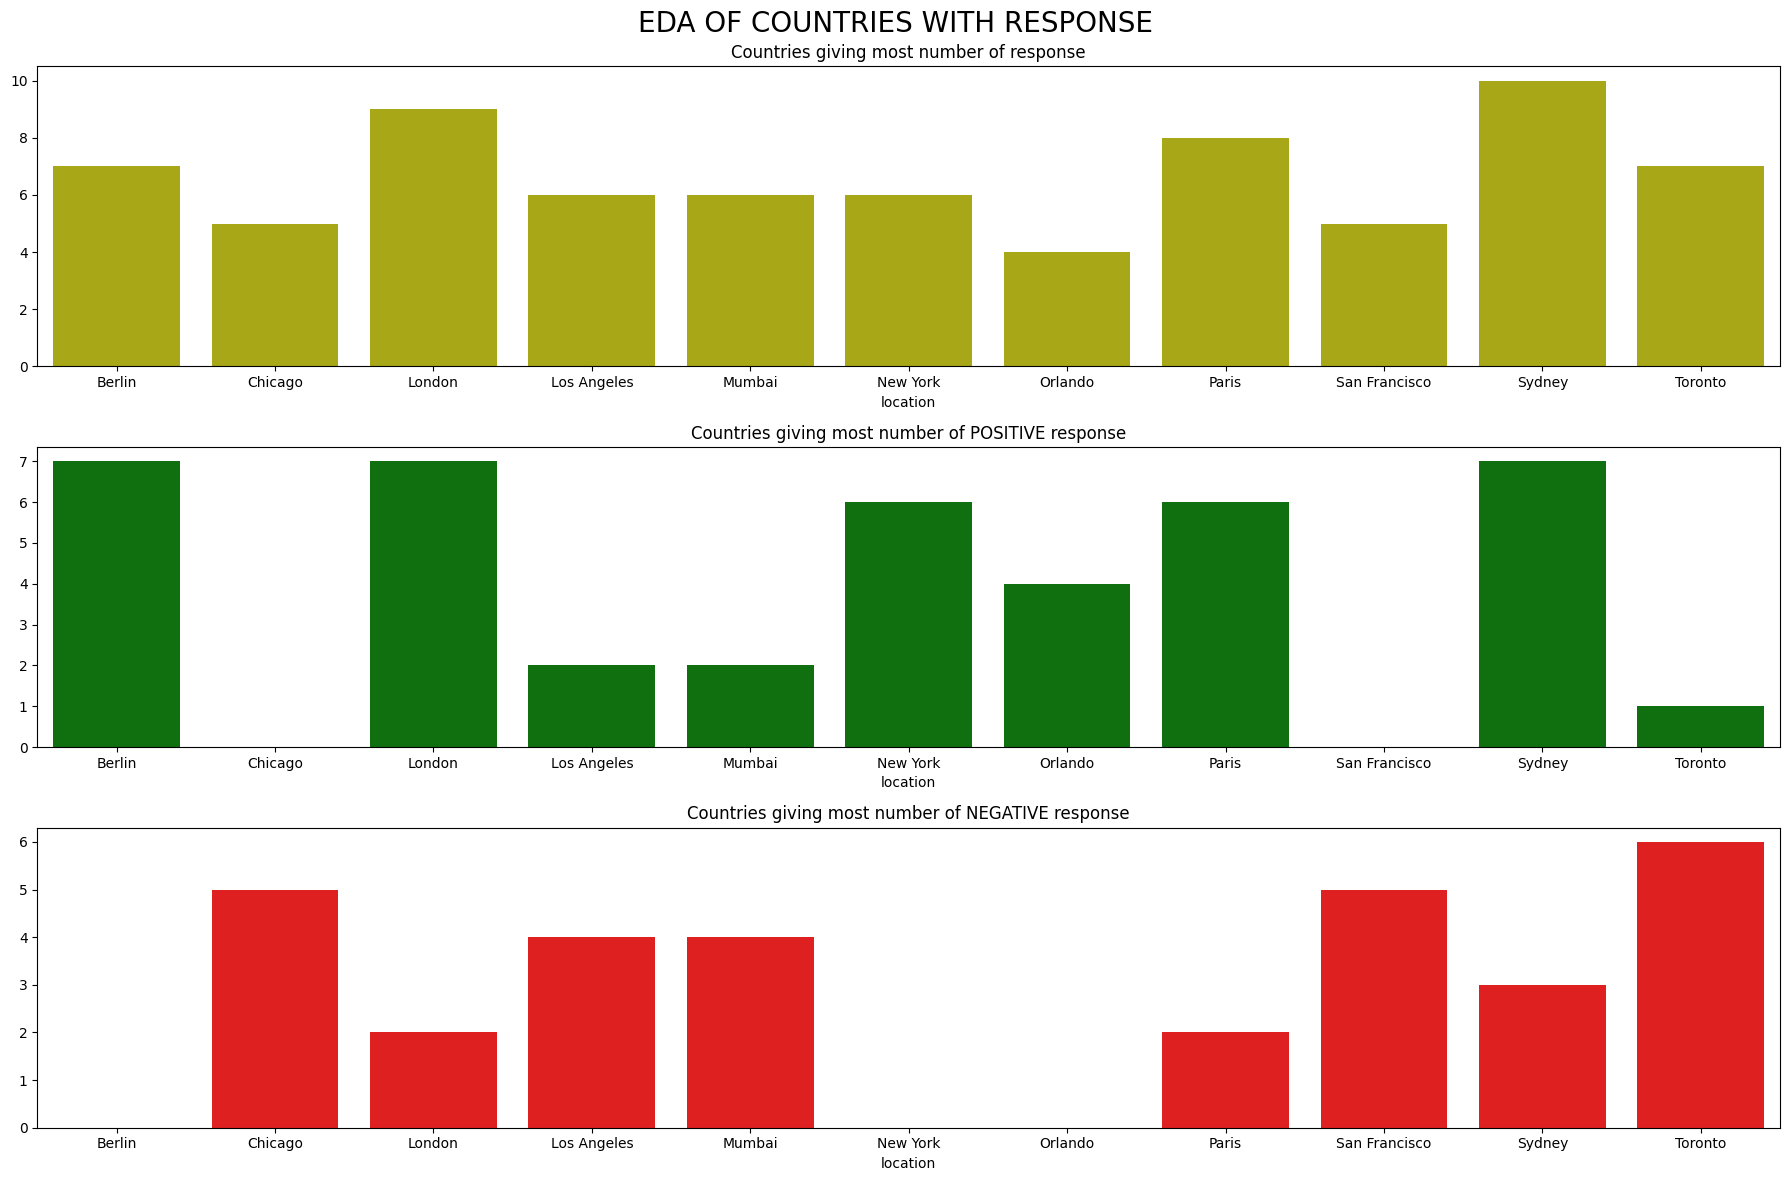

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(18, 12))

sns.barplot(x=location.index, y=location.values, ax=axes[0], color='y', order=location.index)           # location.index -- will bring everything in same order, and leave the places empty that do not have any contribution in positive or negative responses
axes[0].set_title('Countries giving most number of response')

sns.barplot(x=location_positive.index, y=location_positive.values, ax=axes[1], color='g', order=location.index)
axes[1].set_title('Countries giving most number of POSITIVE response')

sns.barplot(x=location_negative.index, y=location_negative.values, ax=axes[2], color='r', order=location.index)
axes[2].set_title('Countries giving most number of NEGATIVE response')

plt.suptitle('EDA OF COUNTRIES WITH RESPONSE', fontsize=20)
plt.tight_layout()
plt.show()